/tmp/ipykernel_1042/2774966319.py:76: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1042/2774966319.py:76: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1042/2774966319.py:76: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

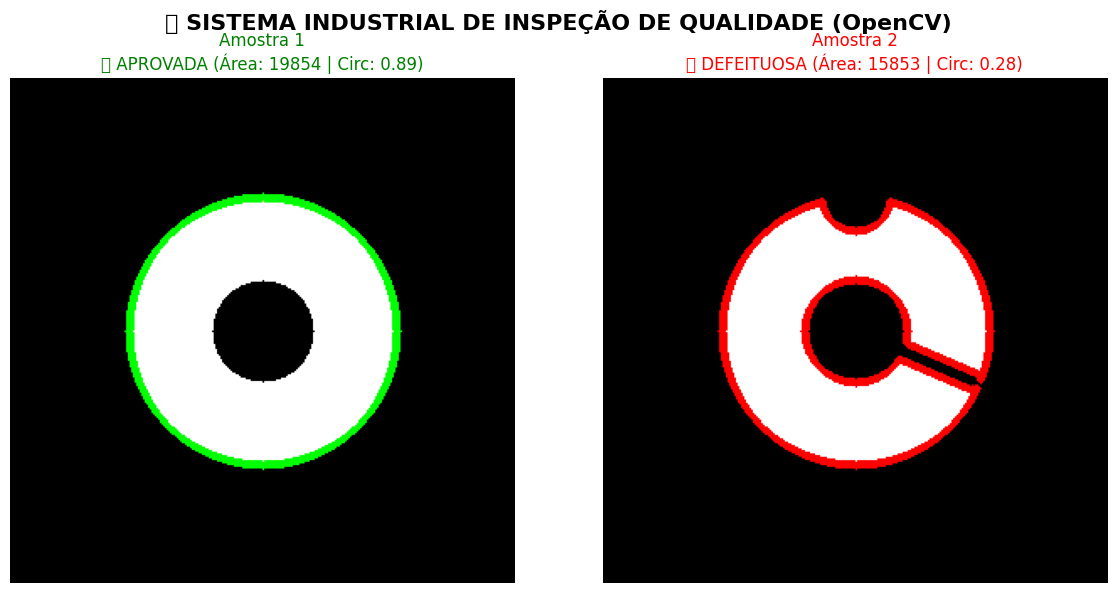

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Função para SIMULAR imagens de peças industriais (Normais vs Com Defeito)
def criar_peca_simulada(com_defeito=False):
    # Criar uma imagem preta de 300x300
    img = np.zeros((300, 300), dtype=np.uint8)

    # Desenhar uma engrenagem/arruela perfeita no centro (branca)
    cv2.circle(img, (150, 150), 80, 255, -1)  # Círculo externo
    cv2.circle(img, (150, 150), 30, 0, -1)    # Furo central

    if com_defeito:
        # Simular uma rachadura/fissura na peça (linha preta cortando a estrutura)
        cv2.line(img, (150, 150), (220, 180), 0, 8)
        # Simular uma deformação na borda
        cv2.circle(img, (150, 70), 20, 0, -1)

    return img

# 2. Função de Inspeção de Qualidade usando OpenCV
def inspecionar_qualidade(img):
    # Aplicar Thresholding (Binarização)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Encontrar contornos na imagem
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Converter para imagem BGR para podermos desenhar resultados coloridos
    img_resultado = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if len(contours) == 0:
        return img_resultado, "🚨 REJEITADO (Sem peça)", (0, 0, 255)

    # Pegar o maior contorno (a peça principal)
    maior_contorno = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(maior_contorno)
    perimetro = cv2.arcLength(maior_contorno, True)

    # Calcular a 'Circularidade' (Métrica de forma: valor perto de 1.0 = círculo perfeito)
    circularidade = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0

    # Regra de Inspeção: Área esperada ~17.000px | Circularidade esperada > 0.70
    if area < 15000 or circularidade < 0.65:
        status = f"🔴 DEFEITUOSA (Área: {int(area)} | Circ: {circularidade:.2f})"
        cor = (0, 0, 255) # Vermelho
    else:
        status = f"🟢 APROVADA (Área: {int(area)} | Circ: {circularidade:.2f})"
        cor = (0, 255, 0) # Verde

    # Desenhar o contorno detectado na peça
    cv2.drawContours(img_resultado, [maior_contorno], -1, cor, 3)

    return img_resultado, status, cor

# 3. Executando o Teste no Colab
peca_ok = criar_peca_simulada(com_defeito=False)
peca_bad = criar_peca_simulada(com_defeito=True)

res_ok, status_ok, _ = inspecionar_qualidade(peca_ok)
res_bad, status_bad, _ = inspecionar_qualidade(peca_bad)

# 4. Plotando os Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(res_ok, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Amostra 1\n{status_ok}", fontsize=12, color='green')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(res_bad, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Amostra 2\n{status_bad}", fontsize=12, color='red')
axes[1].axis('off')

plt.suptitle("🏭 SISTEMA INDUSTRIAL DE INSPEÇÃO DE QUALIDADE (OpenCV)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()